In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ds = xr.open_dataset('/home/junjieyu/Github/RL_CLMU/data/clmu_input/forcing.nc')
ds

<xarray.Dataset> Size: 14MB
Dimensions:                             (time: 210385, x: 1, y: 1)
Coordinates:
  * time                                (time) datetime64[ns] 2MB 2002-01-01 ...
  * x                                   (x) int32 4B 1
  * y                                   (y) int32 4B 1
Data variables: (12/50)
    Prectmms                            (time, y, x) float32 842kB ...
    Wind                                (time, y, x) float32 842kB ...
    Zbot                                (time, x, y) float32 842kB ...
    LWdown                              (time, y, x) float32 842kB ...
    LWdown_qc                           (time) int8 210kB ...
    PSurf                               (time, y, x) float32 842kB ...
    ...                                  ...
    topsoil_clay_fraction               (y, x) float32 4B ...
    topsoil_sand_fraction               (y, x) float32 4B ...
    tree_area_fraction                  (y, x) float32 4B ...
    tree_mean_height                    (y, x) float32 4B ...
    wall_to_plan_area_ratio             (y, x) float32 4B ...
    water_area_fraction                 (y, x) float32 4B ...
Attributes: (12/29)
    title:                      Continuous meterological forcing from UK-King...
    summary:                    Flux tower observations from Kings College, L...
    sitename:                   UK-KingsCollege
    long_sitename:              Kings College, London, United Kingdom
    version:                    v1
    keywords:                   urban, flux tower, eddy covariance, observations
    ...                         ...
    source:                     https://github.com/matlipson/urban-plumber_pi...
    other_references:           ERA5: Copernicus Climate Change Service (C3S)...
    acknowledgements:           Contains modified Copernicus Climate Change S...
    comment:                    Observations from KSSW tower
    history:                    Thu May  2 13:18:48 2024: ncap2 -O -s time=lo...
    NCO:                        netCDF Operators version 4.8.1 (Homepage = ht...

In [3]:
vars = ['Tair', 'Qair', 'SWdown', 'LWdown', 'Prectmms', 'Wind', 'PSurf']
ylabel = ['TBOT [K]', 'QBOT [kg/kg]', 'SWDOWN [W/m2]', 'LWDOWN [W/m2]', 'PRECP [mm/s]', 'WIND [m/s]', 'PBOT [Pa]']
columns = {
    vars[i]: ylabel[i] for i in range(len(vars))
}

In [4]:
df = ds[vars].to_dataframe()
df.describe().rename(columns=columns).round(2)

,TBOT [K],QBOT [kg/kg],SWDOWN [W/m2],LWDOWN [W/m2],PRECP [mm/s],WIND [m/s],PBOT [Pa]
count,210385.00,210385.00,210385.00,210385.00,210385.00,210385.00,210385.00
mean,285.01,0.01,120.32,328.75,0.00,3.52,100834.62
std,5.75,0.00,188.47,40.98,0.00,1.70,1042.80
min,263.62,0.00,0.00,206.67,0.00,0.01,95672.03
25%,280.90,0.00,0.00,300.17,0.00,2.22,100228.71
50%,285.10,0.01,4.78,332.82,0.00,3.29,100920.42
75%,289.26,0.01,182.82,359.98,0.00,4.54,101527.80
max,306.41,0.01,979.99,479.70,0.01,14.37,103722.45


In [5]:
df = df.reset_index()
df['month'] = df['time'].dt.month
df.groupby('month').mean().round(2)['Tair']-273.15

month
1      6.320007
2      6.029999
3      7.690002
4     10.649994
5     13.420013
6     16.510010
7     18.399994
8     18.320007
9     16.089996
10    12.779999
11     9.279999
12     6.480011
Name: Tair, dtype: float32

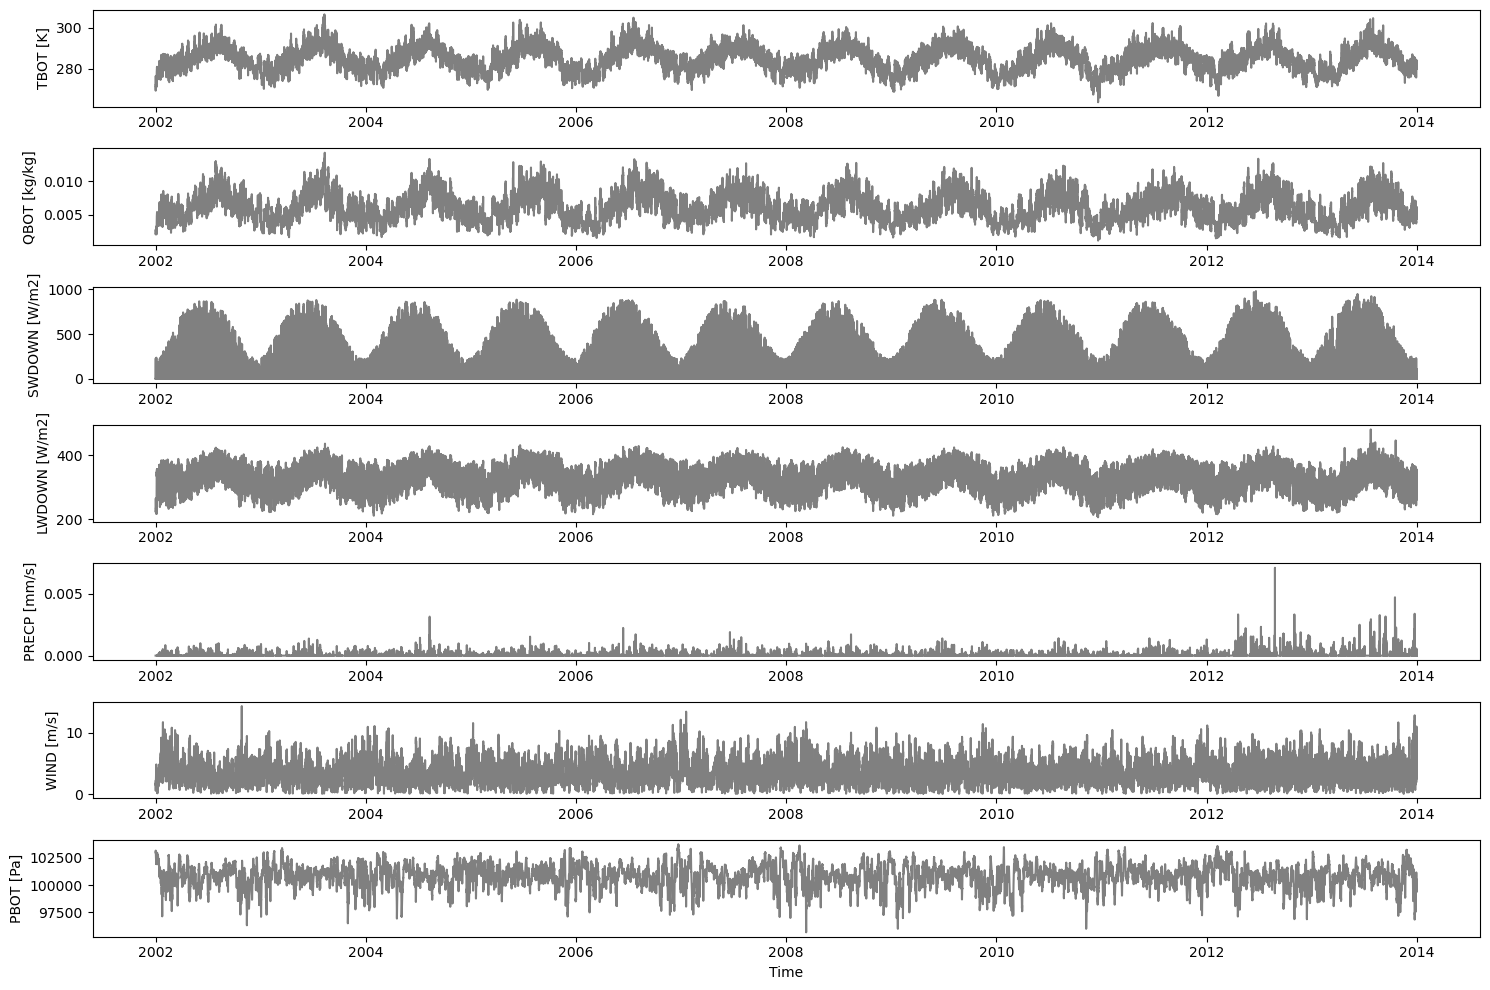

In [6]:

fig = plt.figure(figsize=(15, 10))
i=1
for var in vars:
    ax = fig.add_subplot(len(vars), 1, i)
    ds[var].plot(ax=ax, color='gray')
    ax.set_ylabel(ylabel[i-1])
    ax.set_title('')
    ax.set_xlabel('')
    i += 1
ax.set_xlabel('Time')
plt.tight_layout()
plt.savefig('./figs/forcing_data.pdf', bbox_inches='tight', dpi=300)
plt.show()